In [5]:
# Add import 
import sys
import torch 
from torch import nn
from torch import optim
import tqdm
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")

import numpy as np

%matplotlib inline
# allow reload of python modules
%load_ext autoreload
%autoreload 2
from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy
from dataset import RobotPathDataset
from model.loss import WeightedLoss, ObstacleFreePathLoss
plt.close('all') 
# matplotlib.use('Agg')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
normalizer = MinMaxFeatureNormalizer()
encoder_normalizer = MinMaxFeatureNormalizer()
CONFIG = {
    # Model configuration
    'representation_dim': 64,
    # Hyperparameters for training
    'batch_size': 32,
    'num_epochs': 100,
    'learning_rate': 0.001,
    'optimizer': optim.Adam,
    # Hyperparameters for diffusion process
    'noise_steps': 100,
    'normalize': True,
    'normalizer':normalizer,
    'encoder_normalizer':encoder_normalizer,
    'scheduler': optim.lr_scheduler.ExponentialLR,
    'ema': EMA(0.99),
    'scheduler_gamma': 0.999,

    # Dataset specific configuration
    'n_paths_per_world': 100,
    'n_worlds': 1,
    'n_waypoints': 20,
}

In [7]:
file = '/home/karim.samir.lotfy/adlr/tum-adlr-ss24-09/data/SingleSphere02_all.db'
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'],  n_waypoints=CONFIG['n_waypoints'],   normalizer=CONFIG['normalizer'])
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples')
indx_sample = 5
sample = dataset[indx_sample]

data shape: torch.Size([100, 20, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0'), n_worlds:2, samples: 100
 sample shape torch.Size([20, 2]) with 100 samples


/home/karim.samir.lotfy/adlr/tum-adlr-ss24-09/dataset/RobotPathDataset/torch_dataset.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.data = torch.tensor(path_coordinates, device=device) # torch tensor


# Test Normalizer and Denormalizer

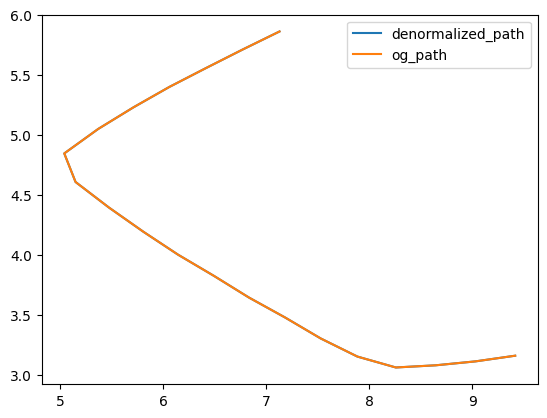

In [8]:
# get a sample from the dataset
indx = 0
sample = dataset[indx]
path = sample['path']
denormalized_path = CONFIG['normalizer'].denormalize(path).detach().cpu().numpy()
og_path = sample['og_path'].detach().cpu().numpy()
# plot the path
plt.figure()
plt.plot(denormalized_path[:, 0], denormalized_path[:, 1], label='denormalized_path')
plt.plot(og_path[:, 0], og_path[:, 1], label='og_path')
plt.legend()

In [9]:
og_path - denormalized_path

array([[0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 2.3841858e-07],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00]], dtype=float32)

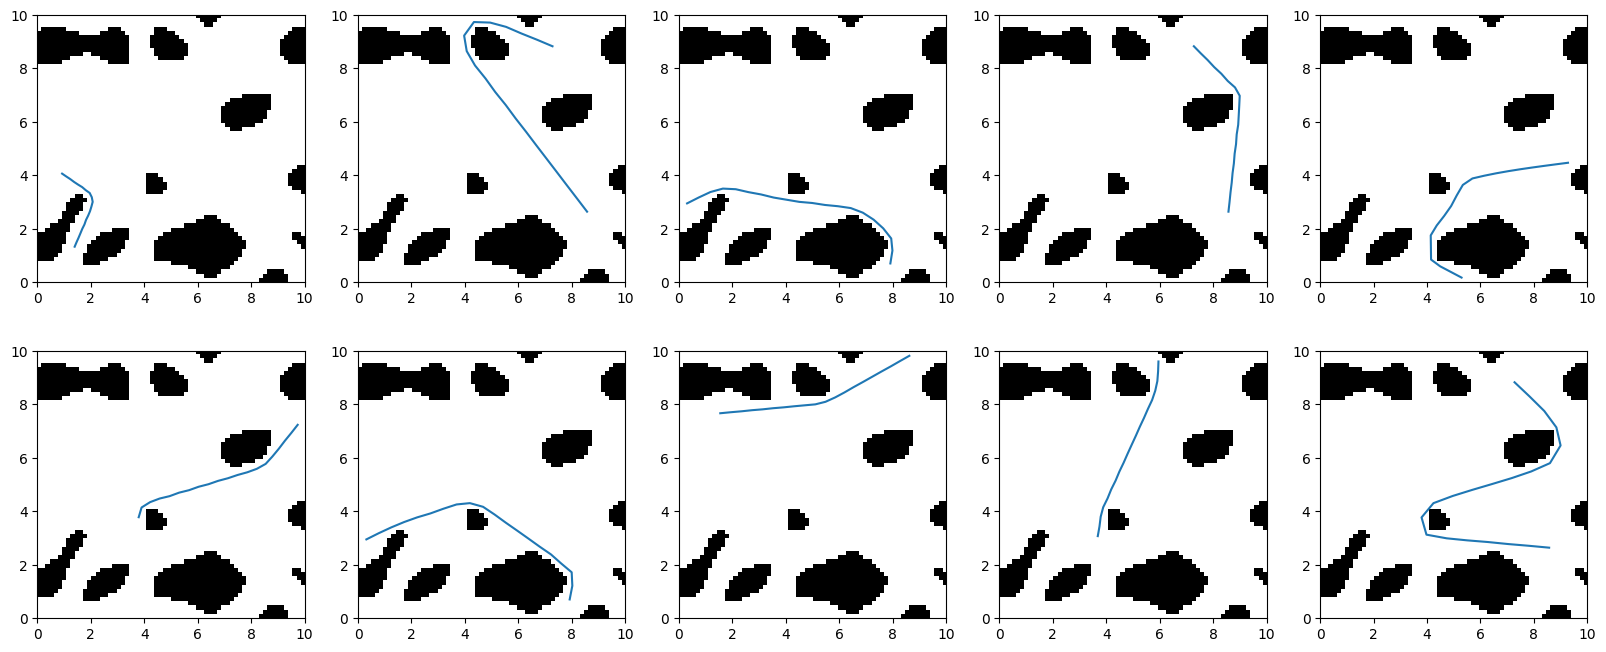

In [10]:
# plot 10 random index samples
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i in range(2):
    for j in range(5):
        indx = np.random.randint(len(dataset))
        sample = dataset[indx]
        sample['path'] = CONFIG['normalizer'].denormalize(sample['path']).cpu().numpy()
        sample['world_img'] = sample['world_img']
        axs[i, j].plot(sample['path'][:, 0], sample['path'][:, 1])
        axs[i, j].imshow(sample['world_img'].T, extent=[0, 10, 0, 10], origin='lower', cmap='binary')


/var/tmp/ipykernel_13663/2520041700.py:3: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3614.)
  plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')


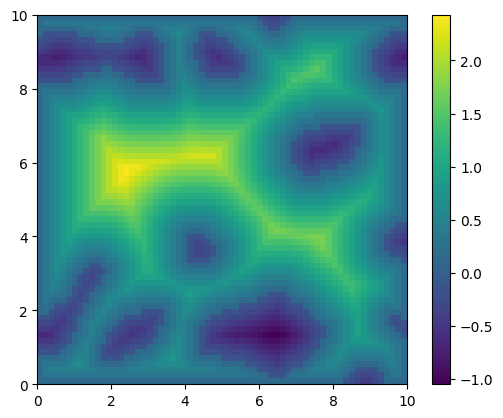

In [11]:
sample = dataset[indx]
dimg = sample['world_distance_field_img']
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
# show the value of colors 
plt.colorbar()

In [12]:
dimg

tensor([[[0.1562, 0.1562, 0.1562,  ..., 0.1562, 0.1562, 0.1562],
         [0.1562, 0.3125, 0.3125,  ..., 0.1562, 0.3125, 0.1562],
         [0.1562, 0.3125, 0.4688,  ..., 0.1562, 0.3125, 0.1562],
         ...,
         [0.1562, 0.3125, 0.3494,  ..., 0.1562, 0.3125, 0.1562],
         [0.1562, 0.3125, 0.3125,  ..., 0.1562, 0.3125, 0.1562],
         [0.1562, 0.1562, 0.1562,  ..., 0.1562, 0.1562, 0.1562]]])

## Analyse nature of dimg

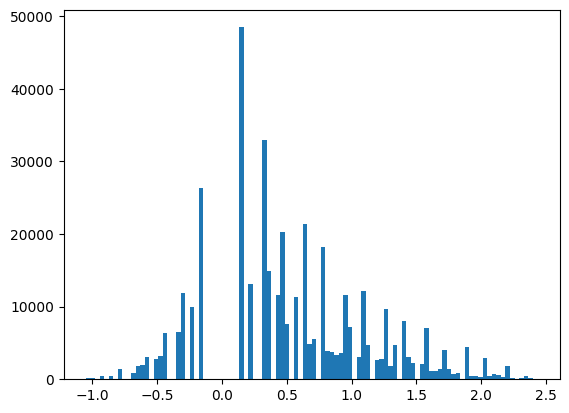

In [13]:
# get hostogram of values 
# sample many points from the dataset
values = []
for i in range(100):
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img']
    values.extend(dimg.flatten());
plt.hist(values, bins=100);

In [14]:
normalizer = MinMaxFeatureNormalizer()
# min_values are a 64 * 64 array filled with -1
min_values = np.ones((64, 64)) * -1
# max_values are a 64 * 64 array filled with 3.5
max_values = np.ones((64, 64)) * 3.5
normalizer.initialize(min_values=min_values, max_values=max_values)

/var/tmp/ipykernel_13663/3545446736.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dimg = torch.tensor(dimg, device='cuda').float()


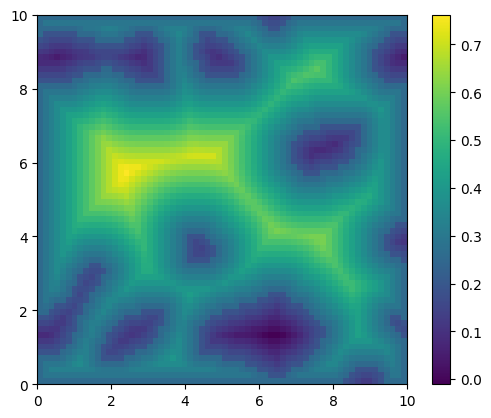

In [15]:
# try to normalize the values using torch layernorm
dimg = torch.tensor(dimg, device='cuda').float()
dimg = normalizer.normalize(dimg)
dimg = dimg.flatten()
dimg = dimg.reshape(64, 64)
plt.imshow(dimg.cpu().detach().numpy().T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.colorbar()

/var/tmp/ipykernel_13663/909360617.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dimg = torch.tensor(dimg, device='cuda').float()


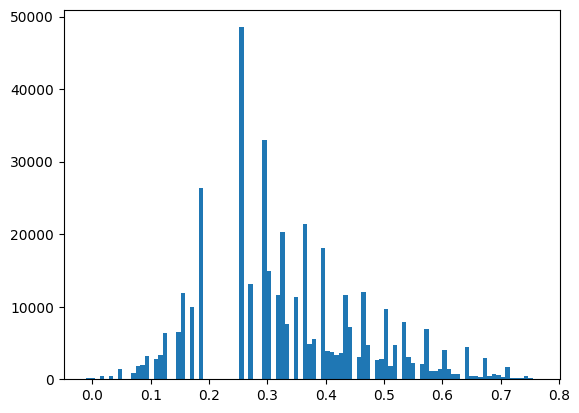

In [16]:
# get hostogram of values 
# sample many points from the dataset
values = []
for i in range(100):
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img']
    # try to normalize the values using torch layernorm
    dimg = torch.tensor(dimg, device='cuda').float()
    dimg = normalizer.normalize(dimg)
    dimg = dimg.flatten()
    dimg = dimg.cpu().detach().numpy()
    values.extend(dimg);
plt.hist(values, bins=100);

/var/tmp/ipykernel_13663/3981840068.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dimg = torch.tensor(dimg).float()


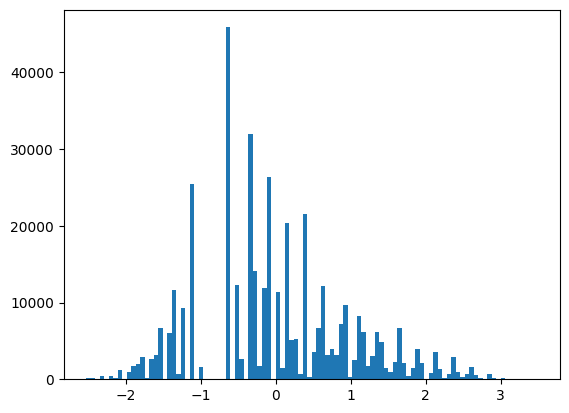

In [17]:
# get hostogram of values 
# sample many points from the dataset
values = []
for i in range(100):
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img']
    # try to normalize the values using torch layernorm
    dimg = torch.tensor(dimg).float()
    norm = nn.LayerNorm(dimg.shape)
    dimg = norm(dimg)
    dimg = dimg.flatten()
    dimg = dimg.cpu().detach().numpy()
    values.extend(dimg);
plt.hist(values, bins=100);

12


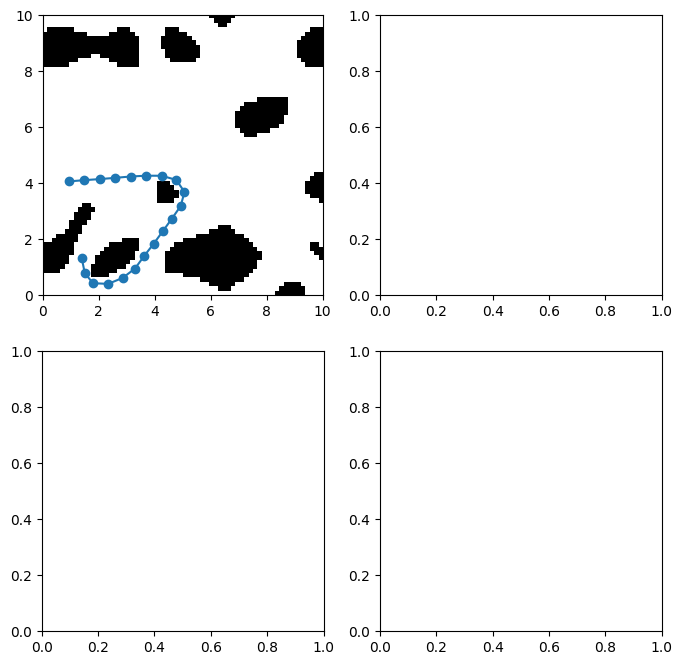

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
indx = 12
print(indx)
sample = dataset[indx]
sample['path'] = CONFIG['normalizer'].denormalize(sample['path']).cpu().numpy()
sample = dataset.get_og_item(indx)
sample['path'] = sample['path'].cpu().numpy()
sample['world_img'] = sample['world_img']
axs[0, 0].plot(sample['path'][:, 0], sample['path'][:, 1], '-o')
axs[0, 0].imshow(sample['world_img'].T, extent=[-0, 10, -0, 10], origin='lower', cmap='binary')
fig.show()

# NEW LOSS FUNCTIONS

## ostacle free loss

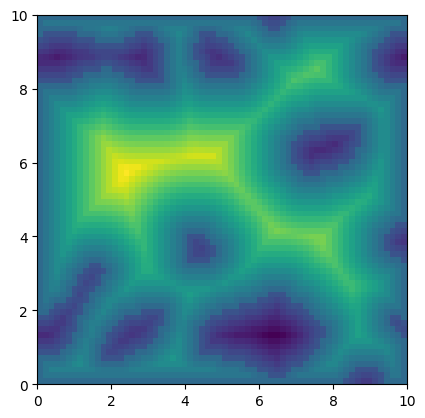

In [19]:
indx = np.random.randint(len(dataset))
# get a random sample 
sample = dataset[indx]
dimg = sample['world_distance_field_img']
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')

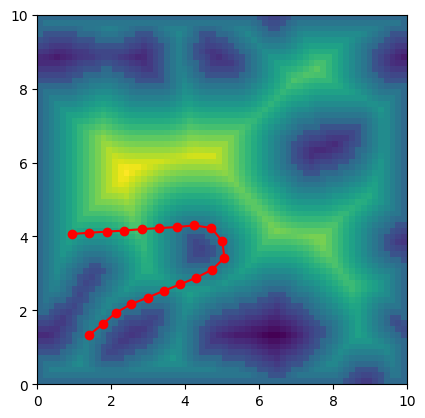

In [20]:
# draw path on top of the distance field
path = sample['og_path'].cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path[:, 0], path[:, 1], '-o', color='red')

In [21]:
loss = ObstacleFreePathLoss(normalizer=None)
indx = np.random.randint(len(dataset))
sample = dataset[indx]
dimg = sample['world_distance_field_img'].to('cuda')
path = sample['og_path']
path = path.unsqueeze(0)
dimg = dimg.unsqueeze(0)
l = loss(path, dimg)
l

tensor(-0.5486, device='cuda:0')

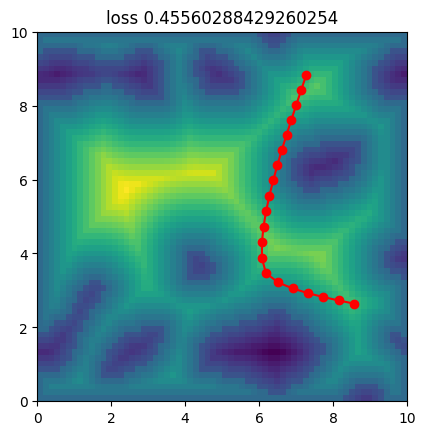

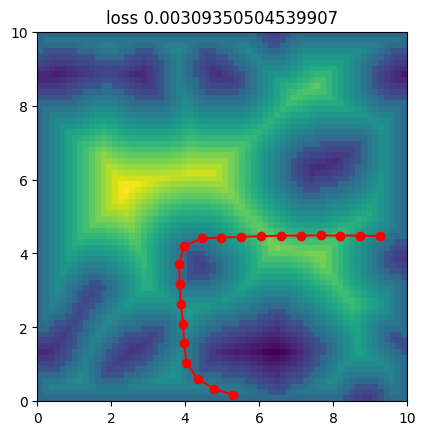

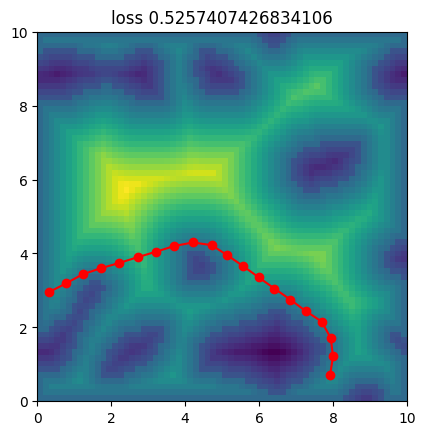

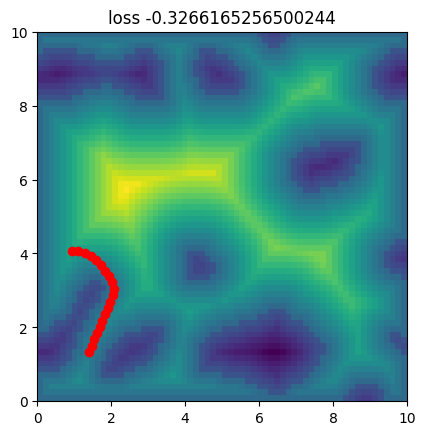

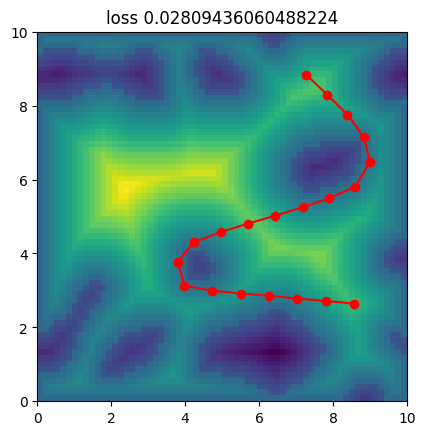

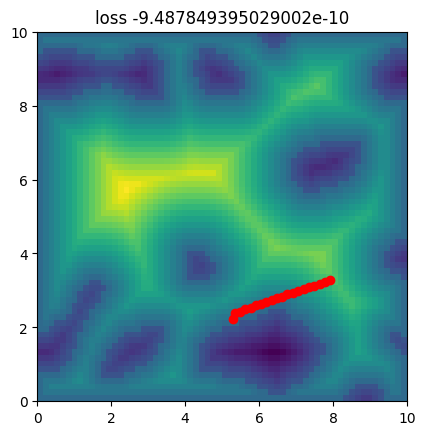

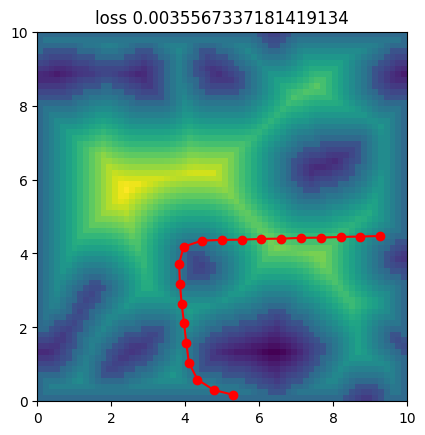

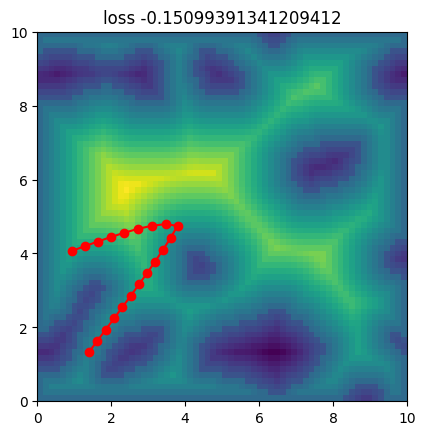

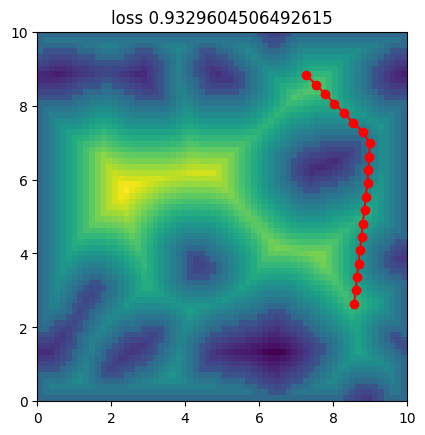

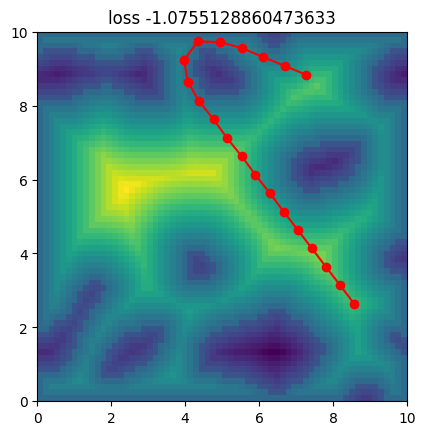

In [22]:
for i in range(10): # plot 10 paths and their distance field
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = loss(path, dimg)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    plt.plot(path[:, 0], path[:, 1], '-o', color='red')
    plt.title(f'loss {l}')
    plt.show()

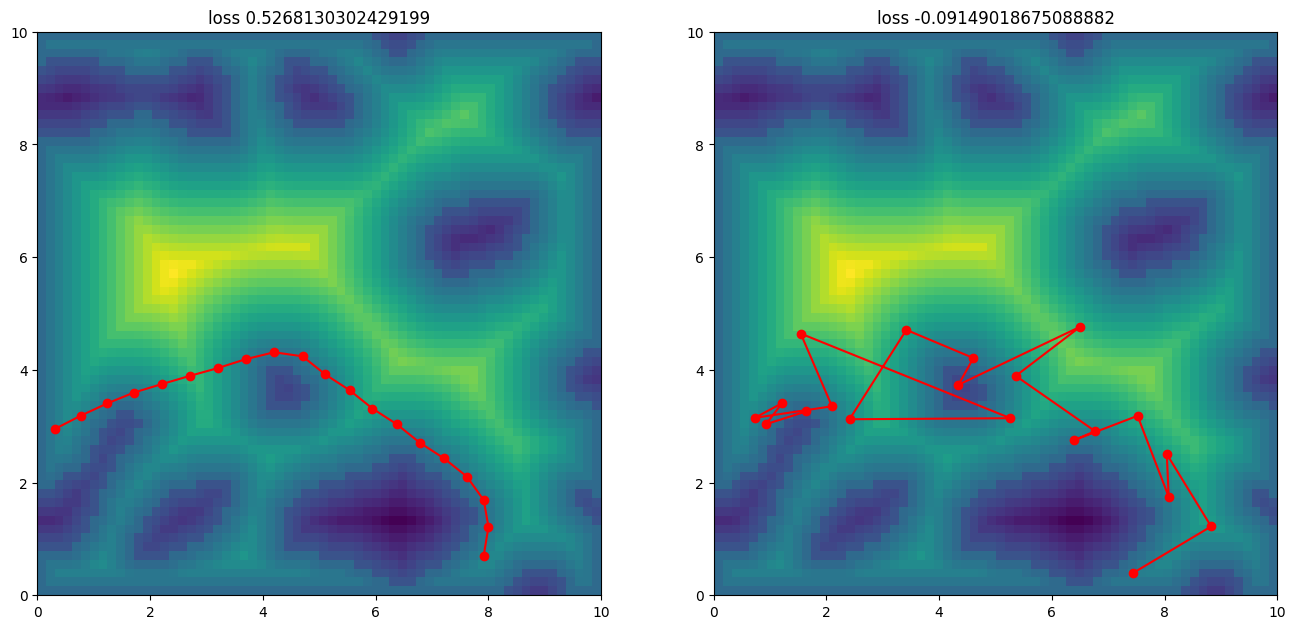

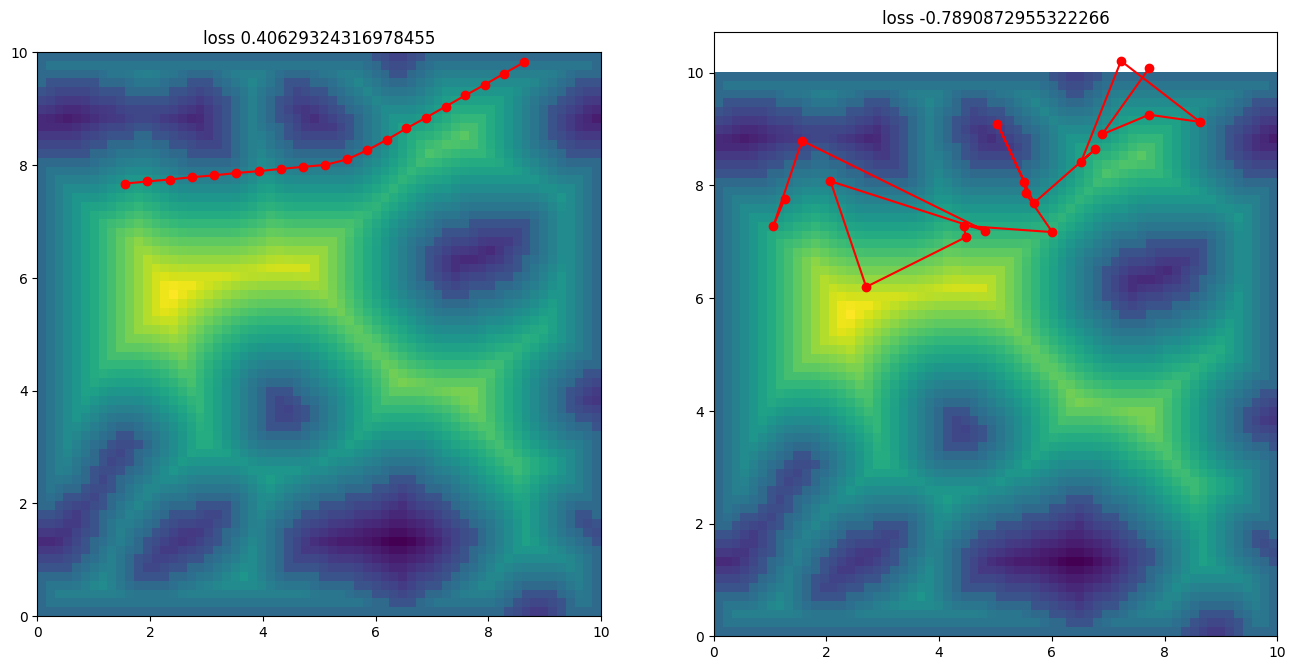

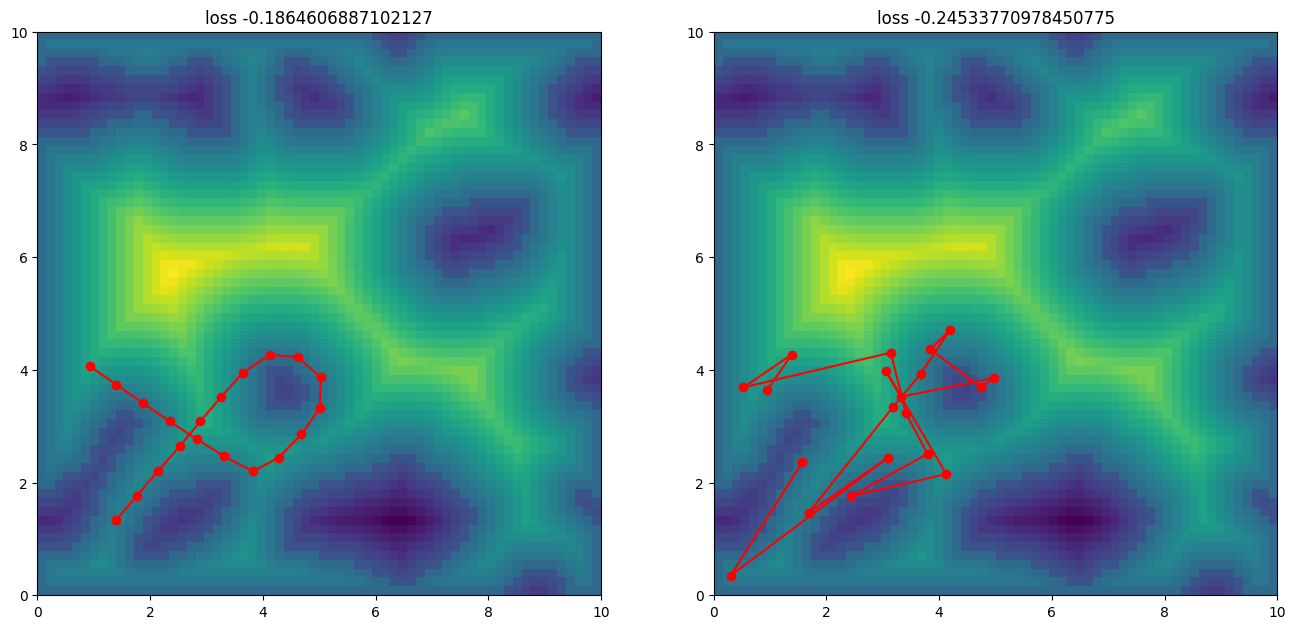

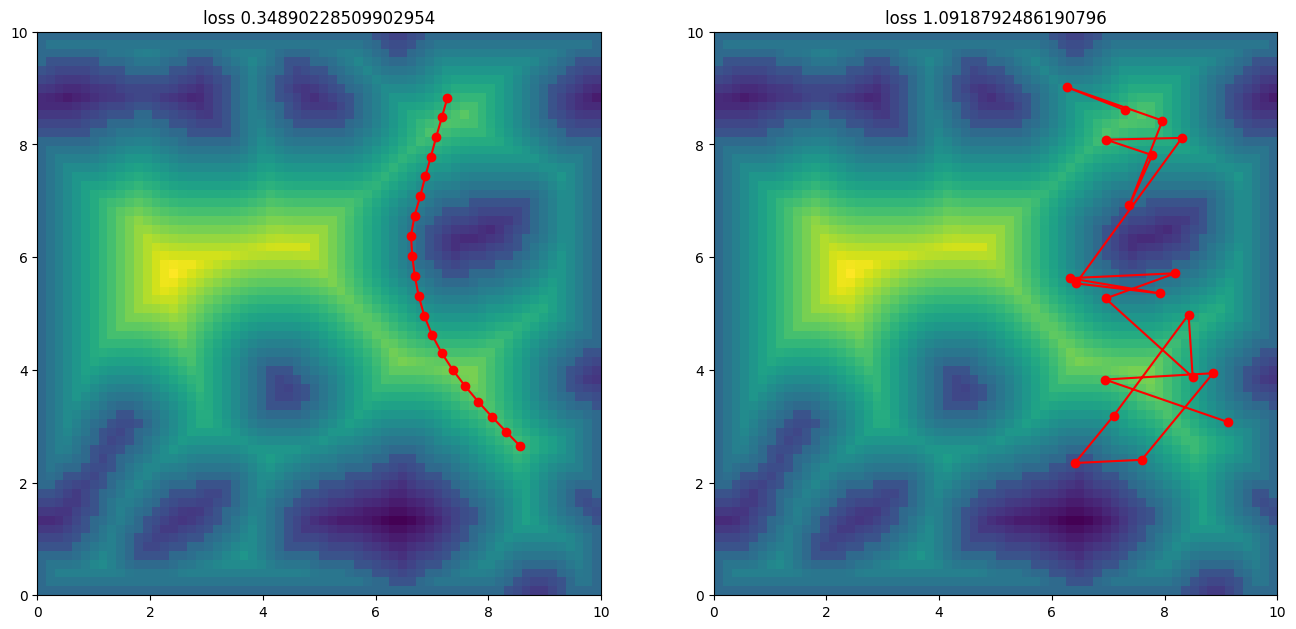

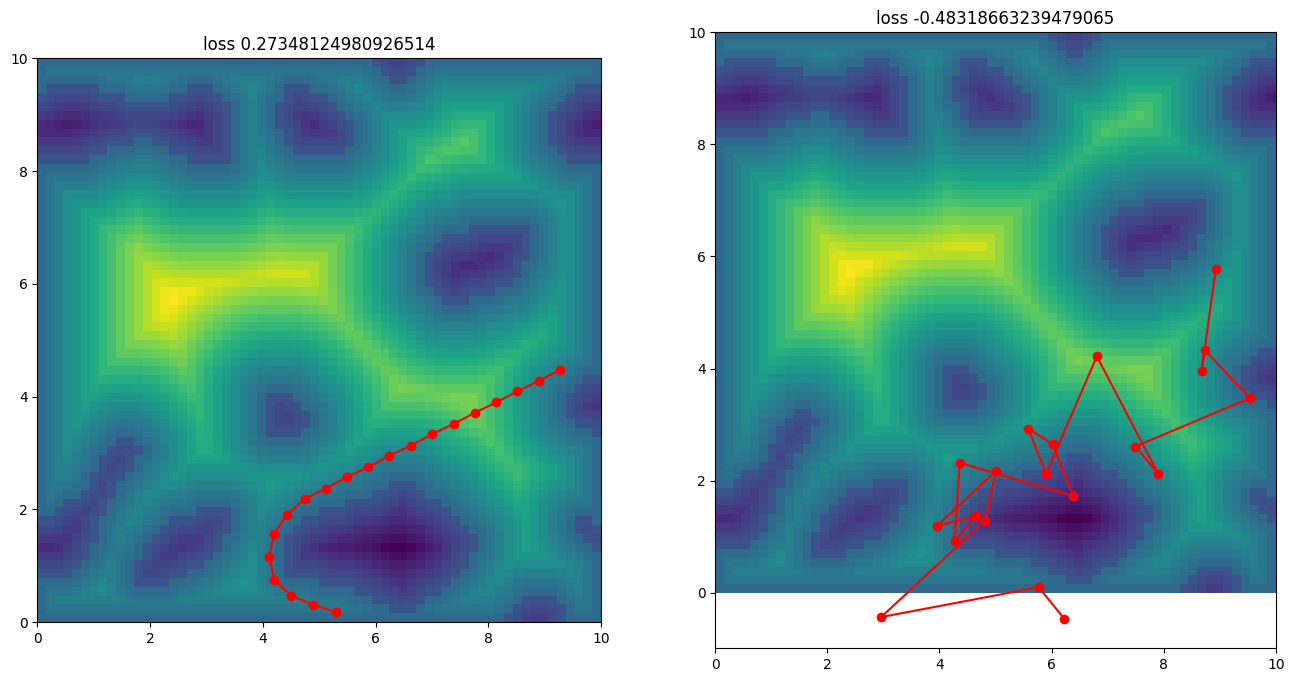

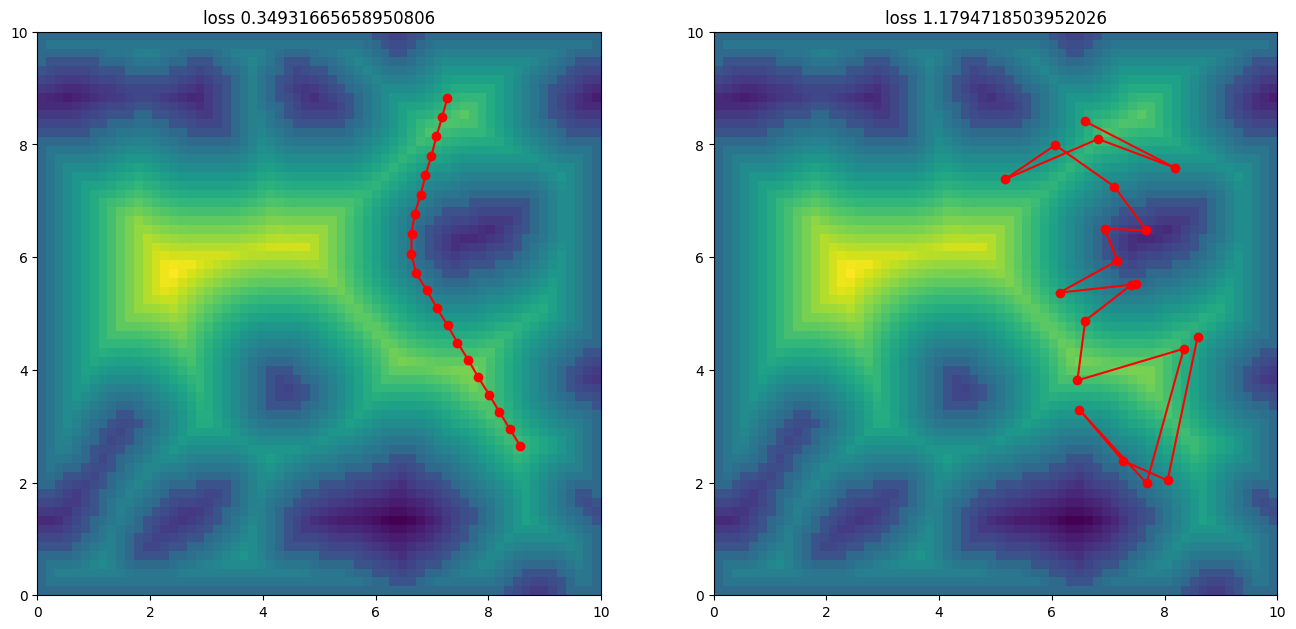

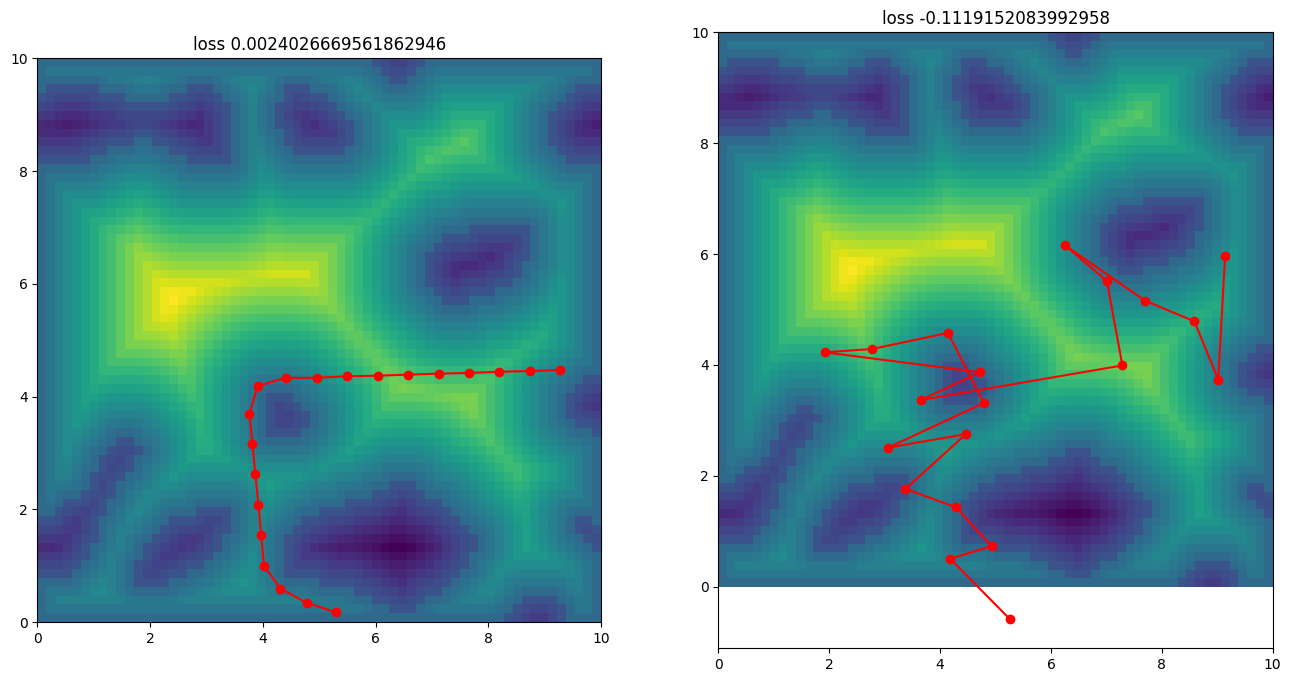

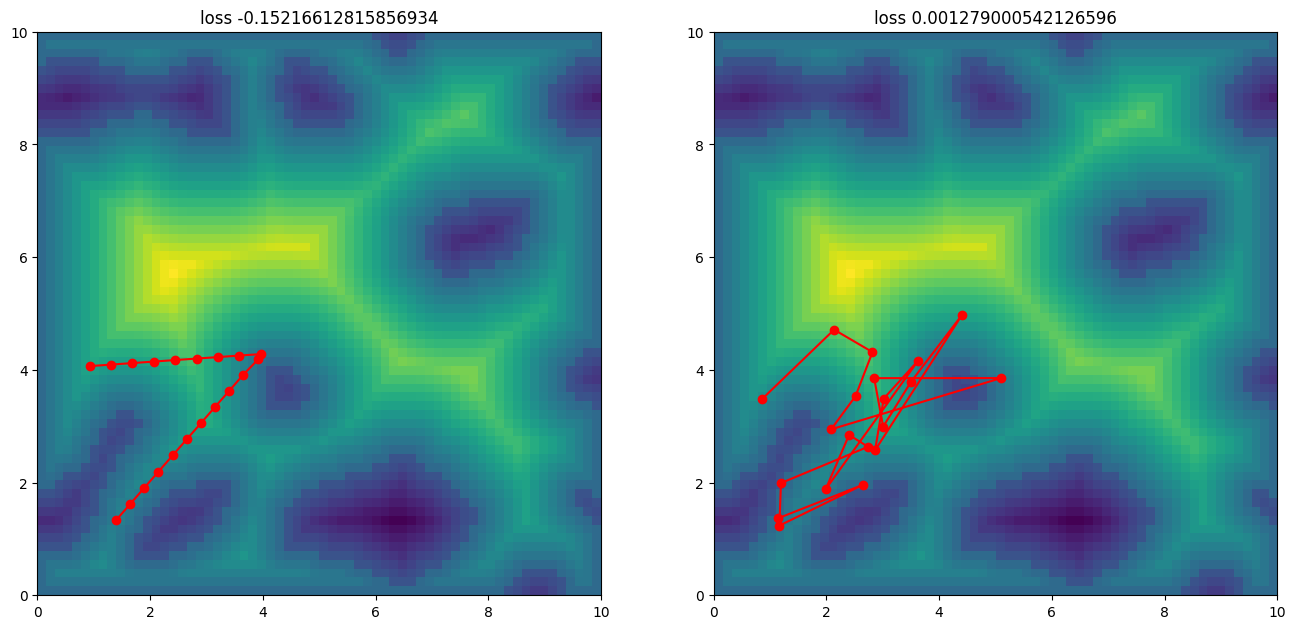

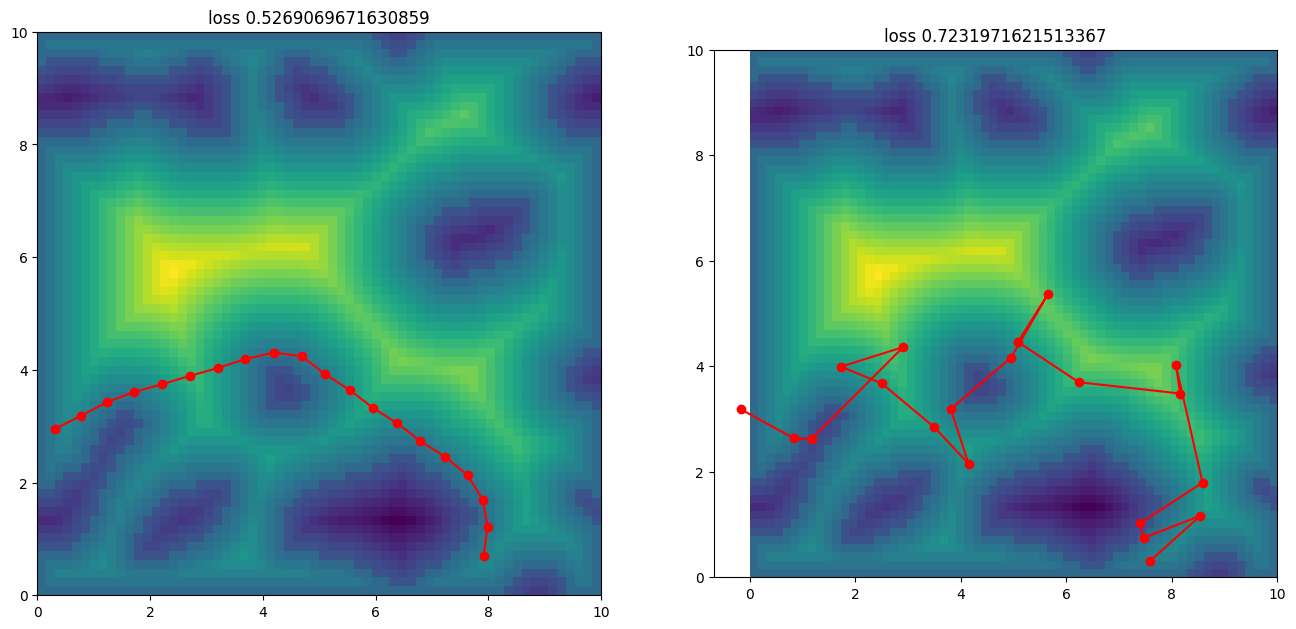

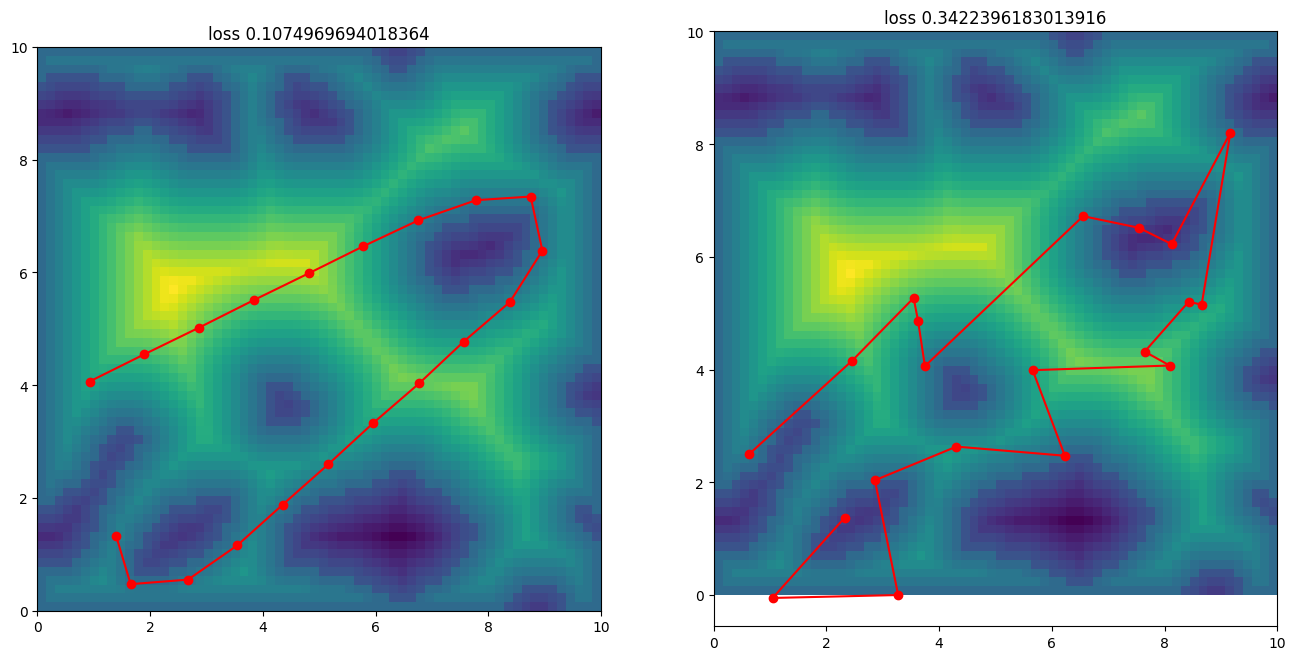

In [23]:
for i in range(10):
    # create a subpolt for 2 graphs
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    # the 1st will be the path and its distance field + loss value 
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = loss(path, dimg)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    axs[0].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[0].plot(path[:, 0], path[:, 1], '-o', color='red')
    axs[0].set_title(f'loss {l}')
    # the 2nd will be the path + some noise and its distance field + loss value
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    noise = torch.randn_like(path) * 0.8
    path = path + noise
    l = loss(path, dimg)
    dimg = sample['world_distance_field_img']
    path = path.cpu().detach().numpy()
    axs[1].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[1].plot(path[0, :, 0], path[0, :, 1], '-o', color='red')
    axs[1].set_title(f'loss {l}')

Text(0.5, 1.0, 'loss 1.30385160446167e-08')

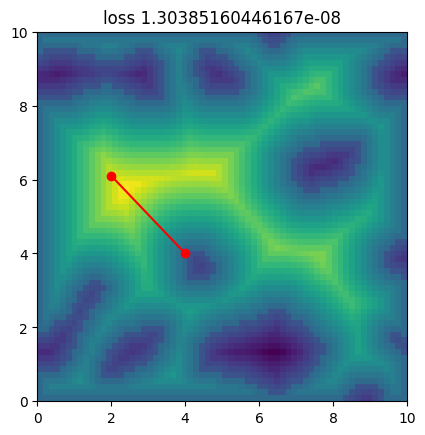

In [24]:

# create my own 2 point path
path = torch.tensor([[2, 6.1], [4, 4]], device='cuda').float()
path = path.unsqueeze(0)
path.requires_grad = True
dimg = sample['world_distance_field_img'].to('cuda')
dimg = dimg.unsqueeze(0)
l = loss(path, dimg)
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'loss {l}')

Text(0.5, 1.0, 'path after optimization')

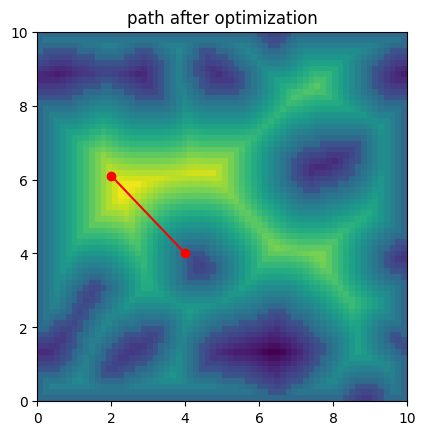

In [25]:
# show the path after the optimization
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'path after optimization')

In [26]:
# take 100 steps of optimization
optimizer = optim.Adam([path], lr=0.01)
for i in range(100):
    dimg = sample['world_distance_field_img'].to('cuda')
    dimg = dimg.unsqueeze(0)
    l = loss(path, dimg)
    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    if i % 10 == 0:
        print(f'loss {l}')

loss 1.30385160446167e-08
loss 1.30385160446167e-08
loss 1.30385160446167e-08
loss 1.30385160446167e-08
loss 1.30385160446167e-08
loss 1.30385160446167e-08
loss 1.30385160446167e-08
loss 1.30385160446167e-08
loss 1.30385160446167e-08
loss 1.30385160446167e-08


In [27]:
path

tensor([[[2.0000, 6.1000],
         [4.0000, 4.0000]]], device='cuda:0', requires_grad=True)

Text(0.5, 1.0, 'path after optimization')

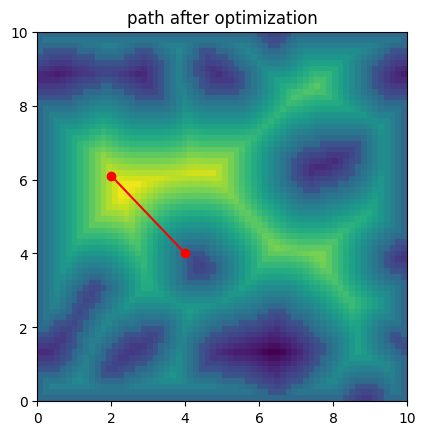

In [28]:
# show the path after the optimization
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'path after optimization')

In [29]:
path = torch.tensor([[2, 6.1], [4, 4]], device='cuda').float()
path = path.unsqueeze(0)
path.requires_grad = True
path_true_points = torch.tensor([[[4, 8], [6.5, 4.5]]], device='cuda').float()


In [30]:
# take 100 steps of optimization
optimizer = optim.Adam([path], lr=0.01)
for i in range(100):
    dimg = sample['world_distance_field_img'].to('cuda')
    dimg = dimg.unsqueeze(0)
    l1 = loss(path, dimg)
    l2 = nn.MSELoss()(path, path_true_points)
    l = l1 + l2
    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    if i % 10 == 0:
        print(f'loss {l}')

loss 3.5275001525878906
loss 3.193129539489746
loss 2.881812810897827
loss 2.594949722290039
loss 2.33229398727417
loss 2.0924482345581055
loss 1.8735435009002686
loss 1.6737644672393799
loss 1.4915804862976074
loss 1.3257431983947754


Text(0.5, 1.0, 'path after optimization')

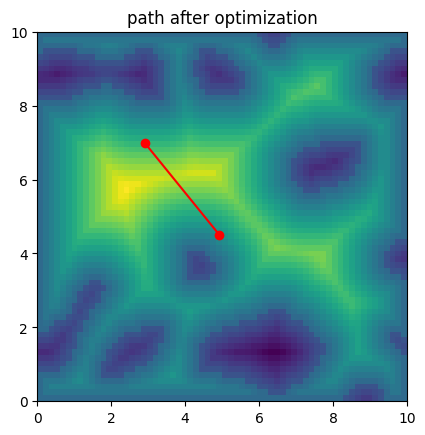

In [31]:
# show the path after the optimization
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'path after optimization')

In [32]:
path

tensor([[[2.9016, 6.9956],
         [4.9235, 4.5039]]], device='cuda:0', requires_grad=True)

## Loss for waypoint consitency

In [33]:
import torch
import torch.nn as nn

from model.loss import GraphBasedConsistencyLoss
loss_fn = GraphBasedConsistencyLoss()

In [34]:
import torch
import torch.nn as nn

class GraphBasedConsistencyLoss(nn.Module):
    def __init__(self, variance_weight=1.0):
        super(GraphBasedConsistencyLoss, self).__init__()
        self.variance_weight = variance_weight
    
    def forward(self, paths):
        """
        Args:
            paths (torch.Tensor): Tensor of shape (Batch, Waypoints, 2) where 2 is for (x, y) coordinates.
        
        Returns:
            torch.Tensor: The graph-based consistency loss with variance penalty.
        """
        # Compute the differences between consecutive waypoints
        differences = paths[:, 1:, :] - paths[:, :-1, :]
        
        # Compute the Euclidean distances for these differences
        distances = torch.norm(differences, dim=-1)
        
        # Compute the mean distance
        mean_distance = distances.mean(dim=-1, keepdim=True)
        
        # Compute the variance of the distances
        variance = ((distances - mean_distance) ** 2).mean(dim=-1)
        
        # Sum the distances to get the consistency loss
        consistency_loss = distances.sum(dim=-1).mean()
        
        # Compute the variance penalty
        variance_penalty = variance.mean()
        
        # Total loss
        # loss = consistency_loss + self.variance_weight * variance_penalty
        loss = variance_penalty
        
        return loss

# Example usage
if __name__ == "__main__":
    # Example paths tensor of shape (Batch, Waypoints, 2)
    paths = torch.tensor([[[0.0, 0.0], [1.0, 1.0], [2.0, 2.0]],
                          [[0.0, 1.0], [1.0, 2.0], [2.0, 3.0]]], dtype=torch.float32)
    
    # Initialize the loss function with a variance weight
    loss_fn = GraphBasedConsistencyLoss(variance_weight=1.0)
    
    # Compute the loss
    loss = loss_fn(paths)
    
    print("Graph-Based Consistency Loss with Variance Penalty:", loss.item())


Graph-Based Consistency Loss with Variance Penalty: 0.0


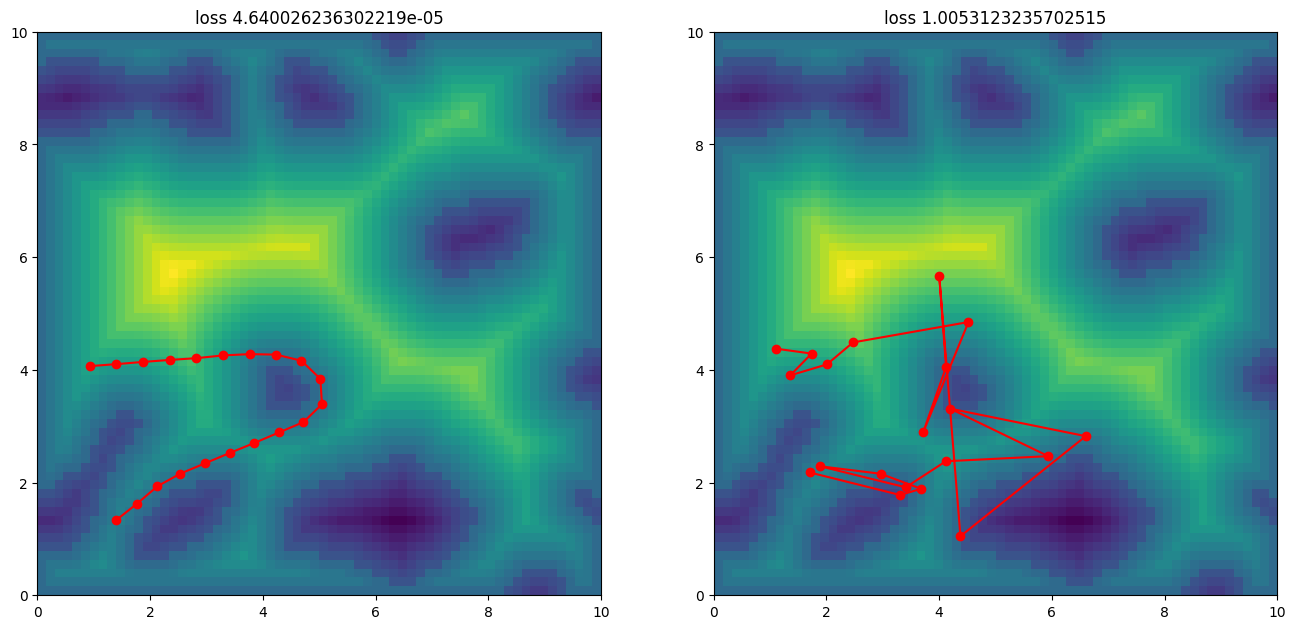

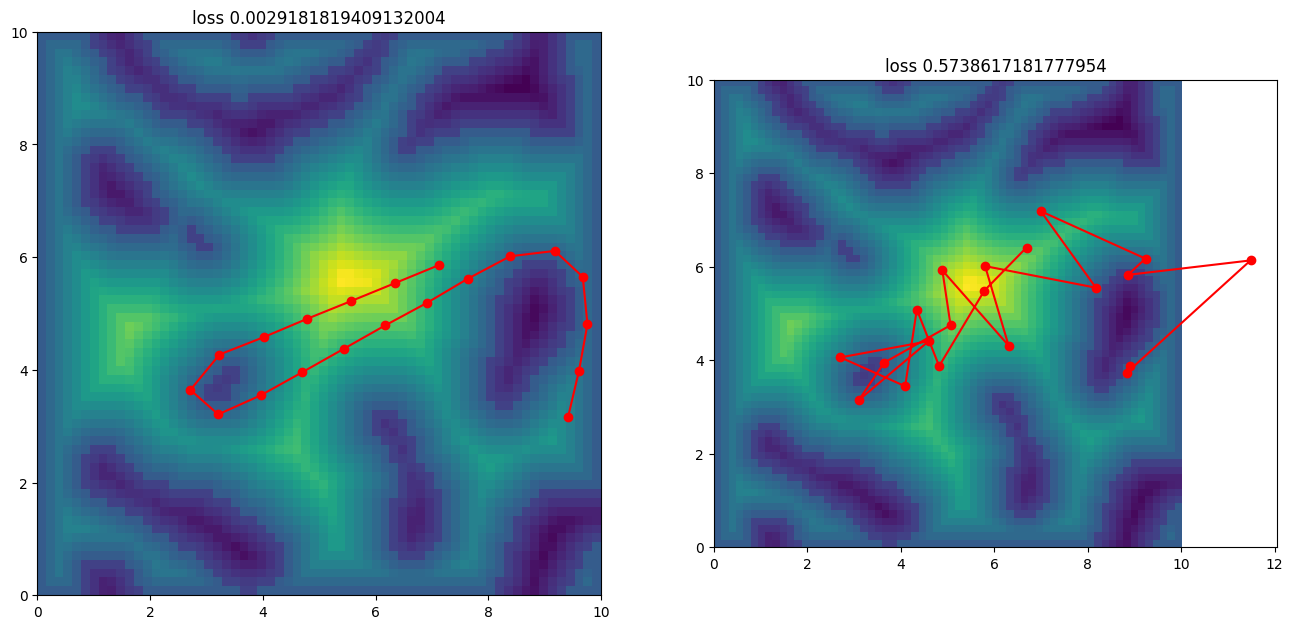

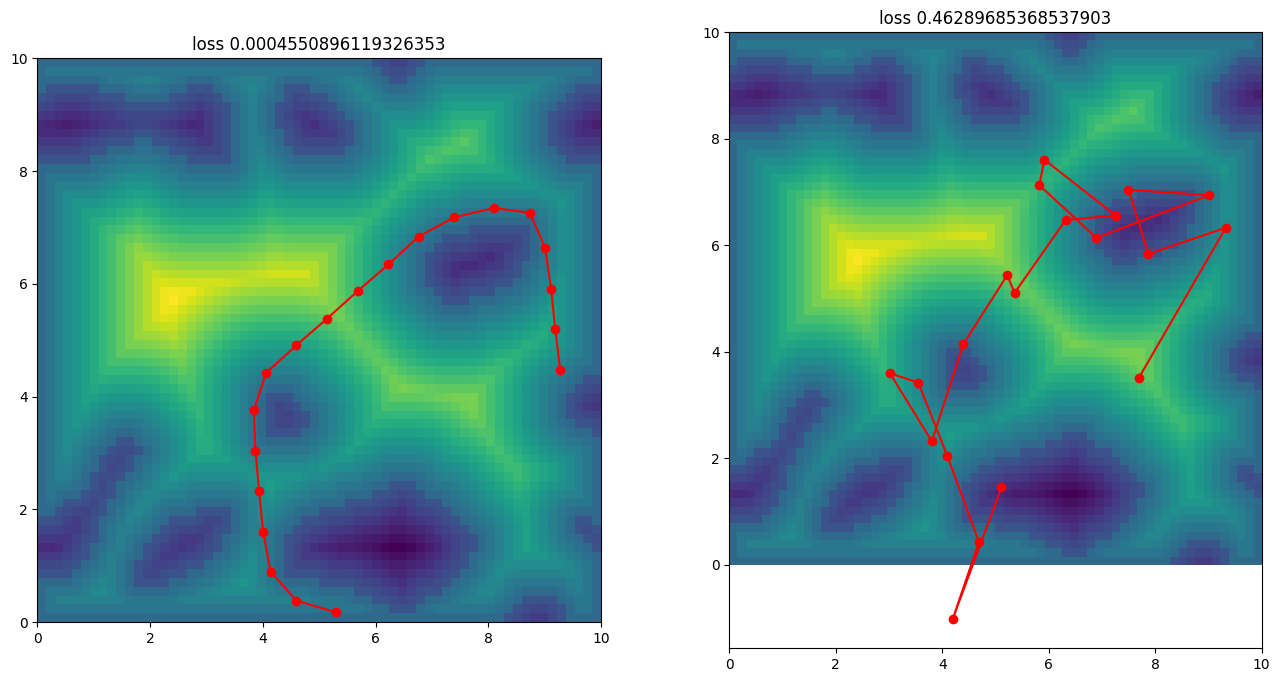

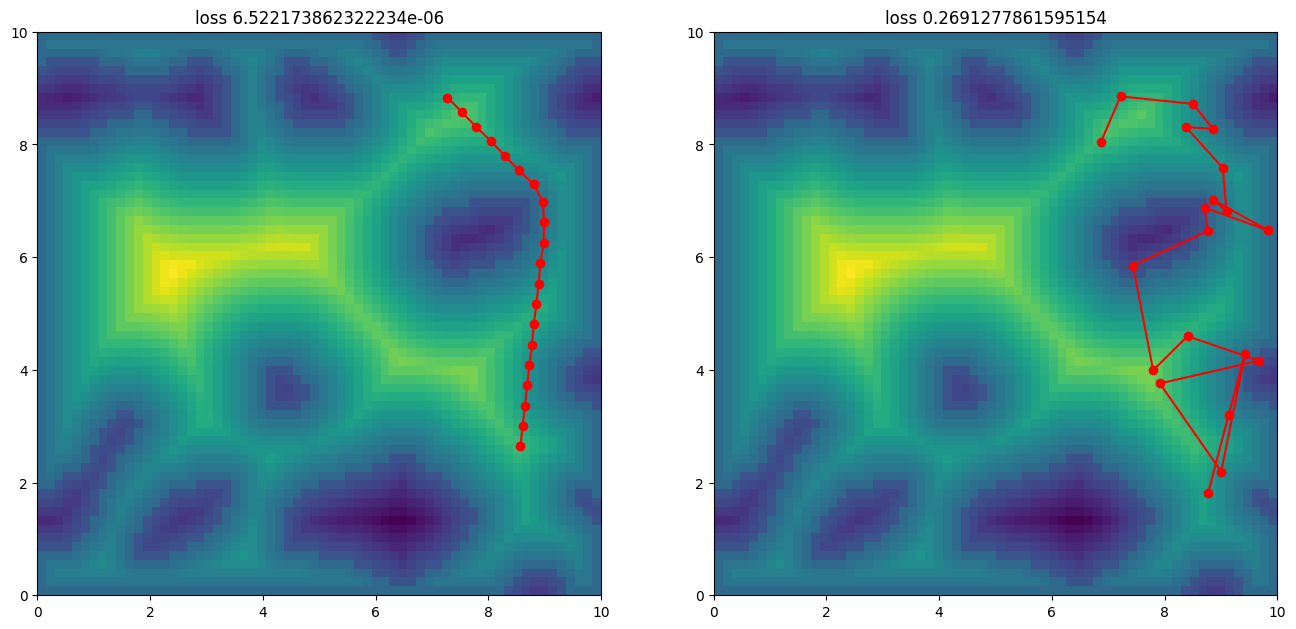

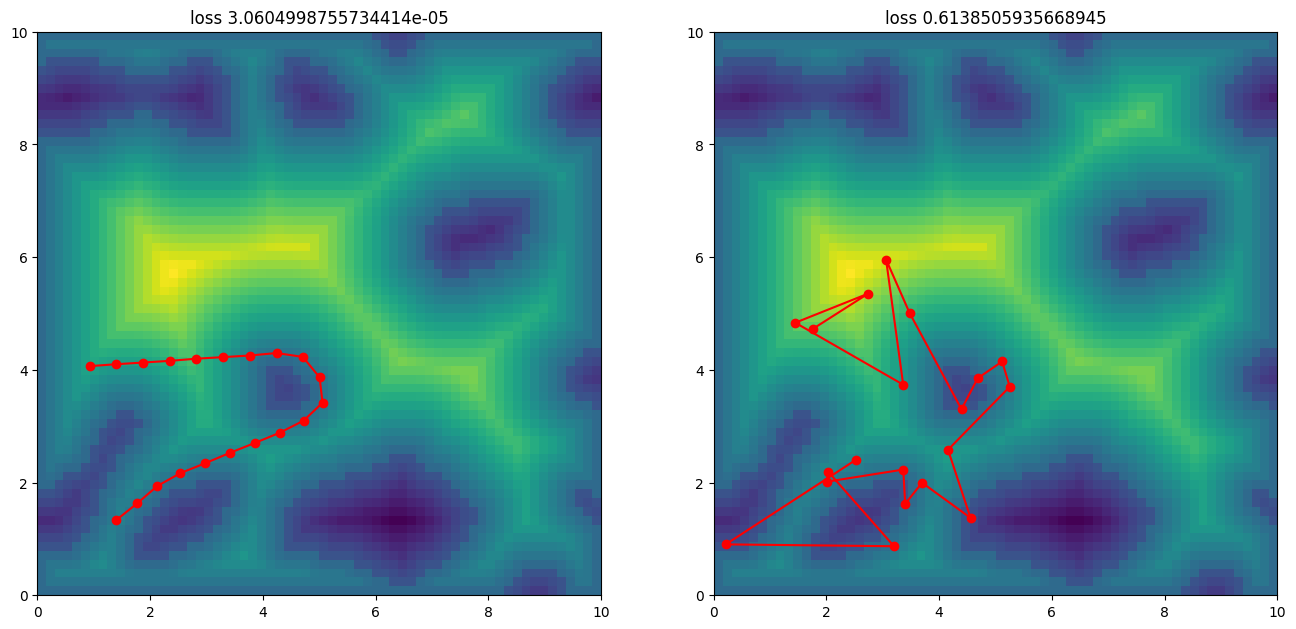

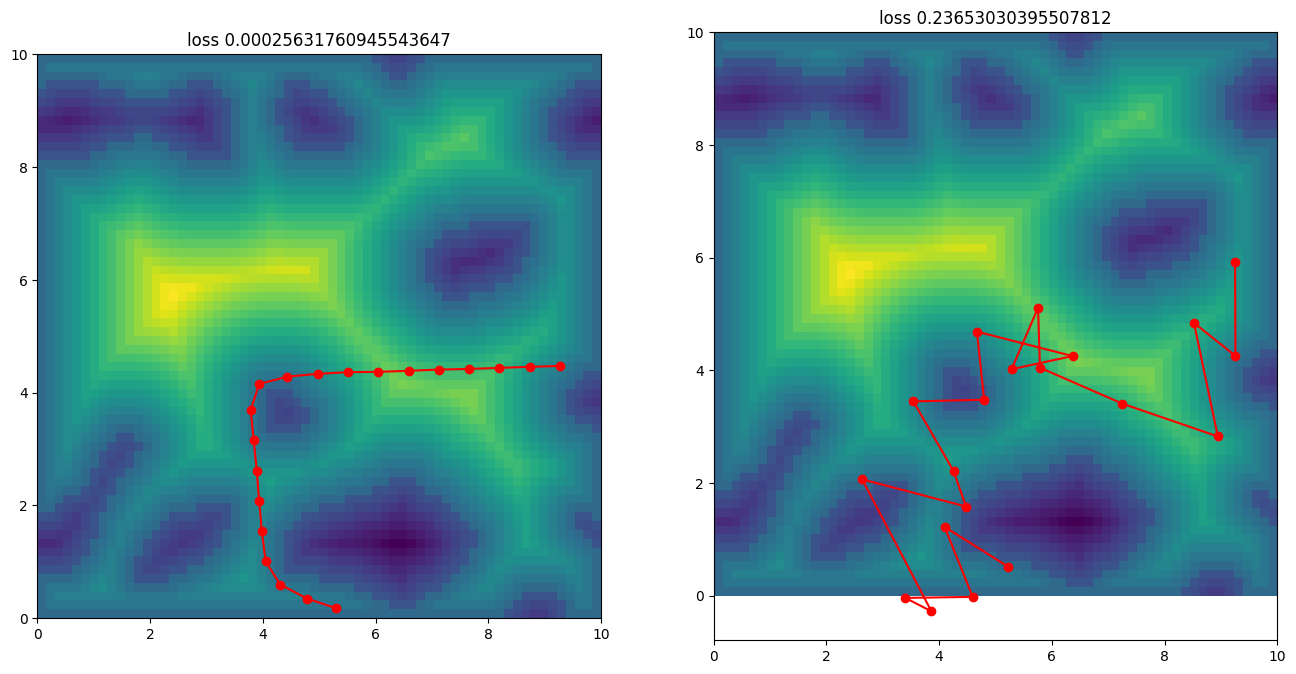

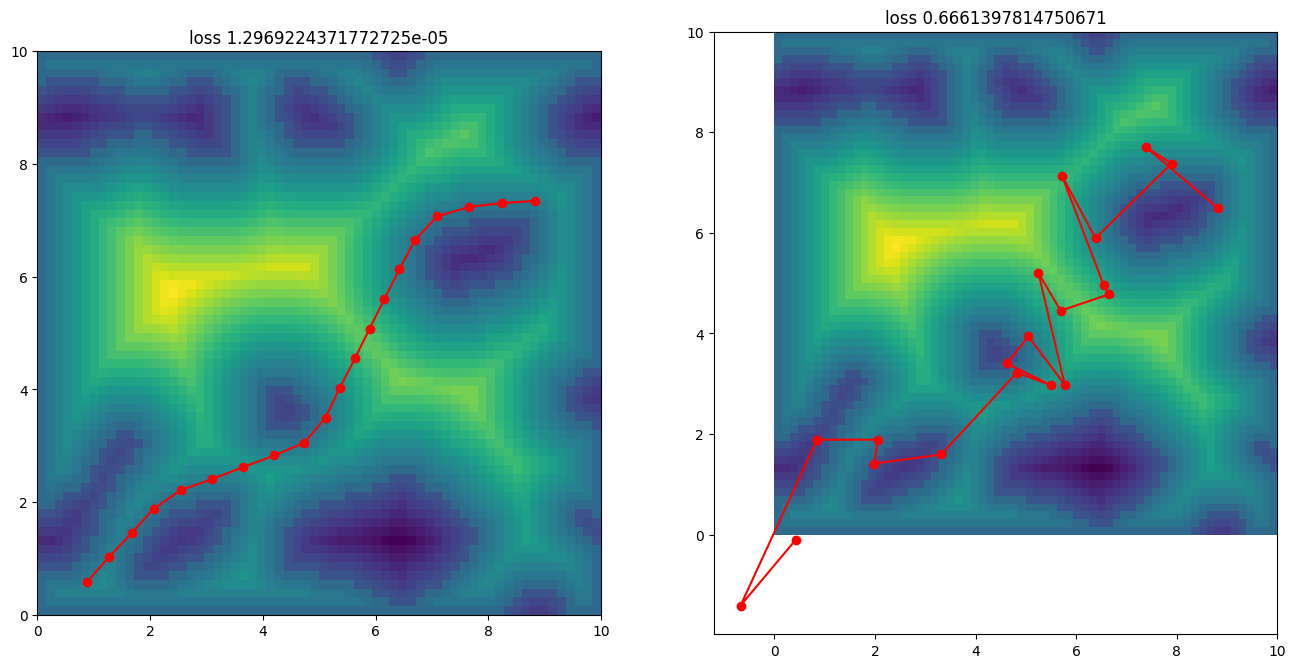

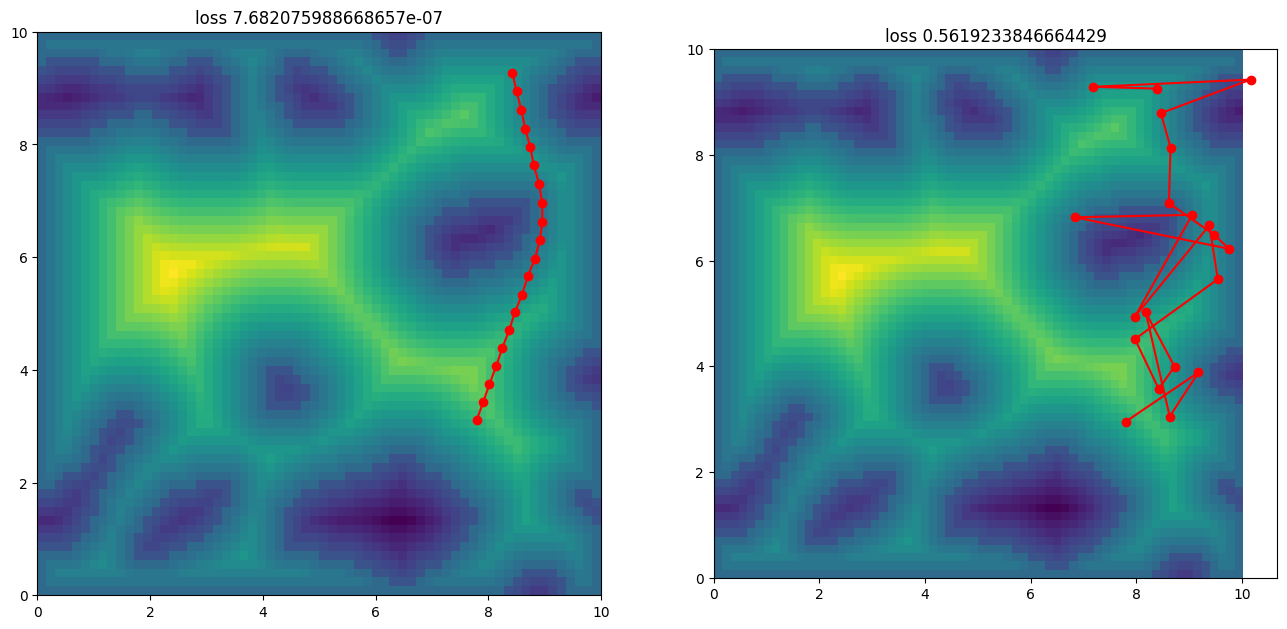

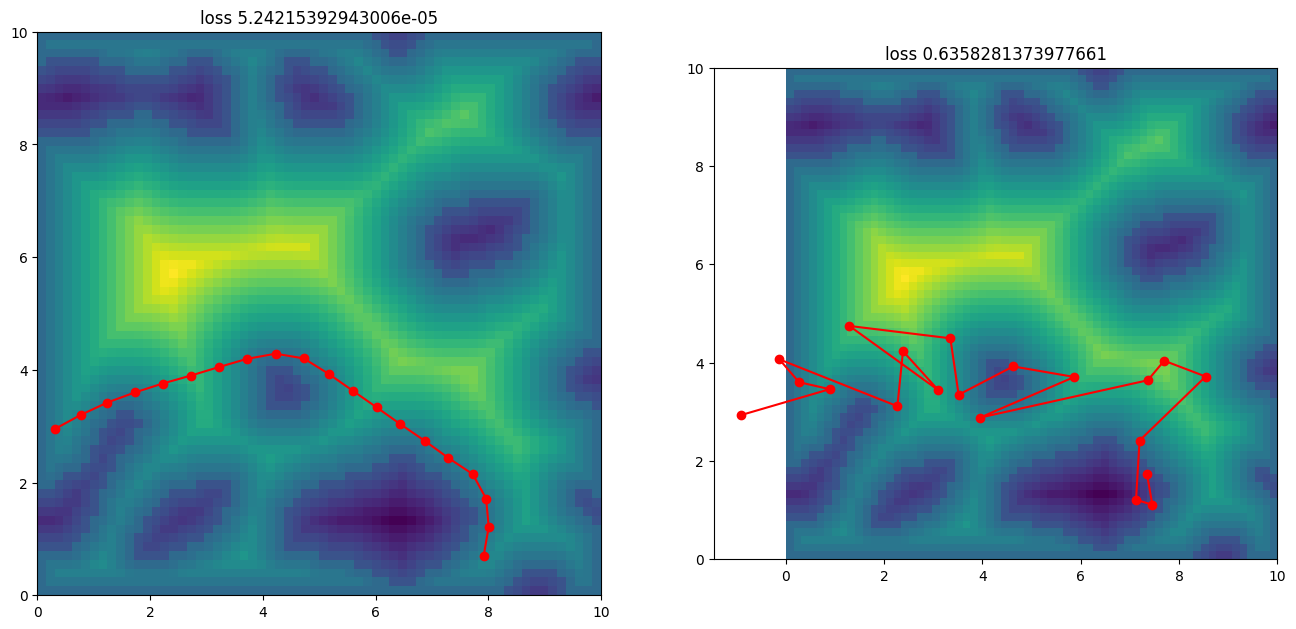

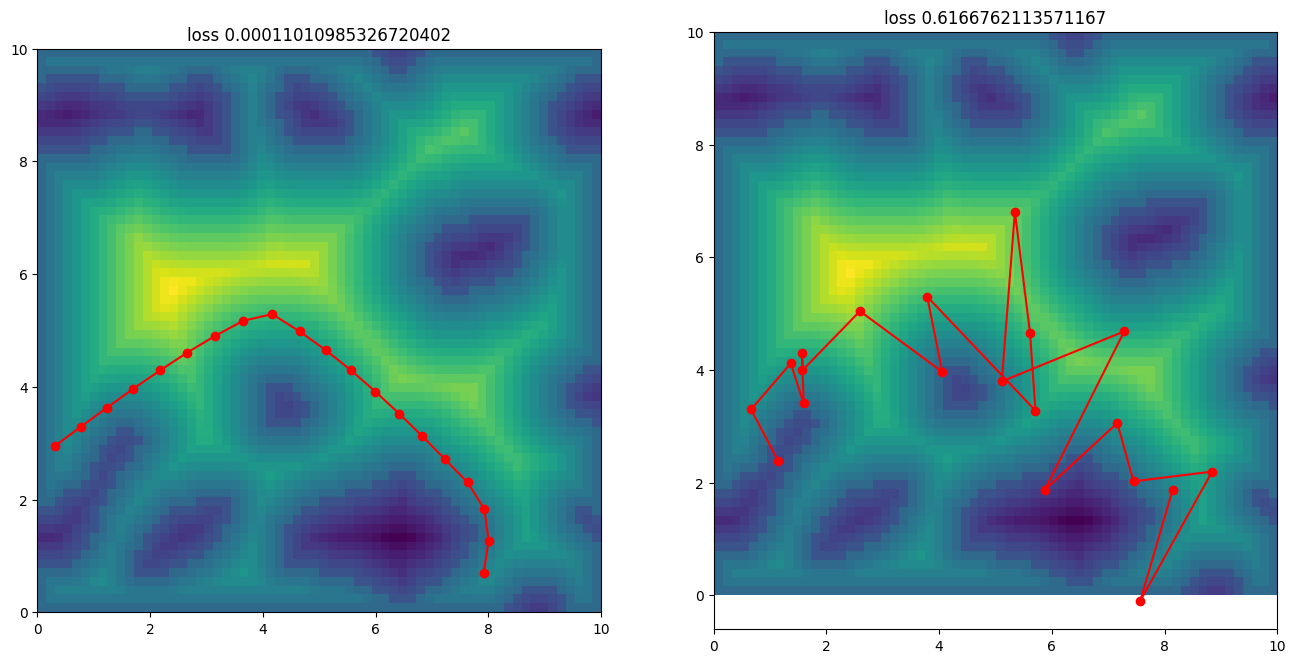

In [35]:
for i in range(10):
    # create a subpolt for 2 graphs
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    # the 1st will be the path and its distance field + loss value 
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = loss_fn(path)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    axs[0].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[0].plot(path[:, 0], path[:, 1], '-o', color='red')
    axs[0].set_title(f'loss {l}')
    # the 2nd will be the path + some noise and its distance field + loss value
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    noise = torch.randn_like(path) * 0.8
    path = path + noise
    l = loss_fn(path)
    dimg = sample['world_distance_field_img']
    path = path.cpu().detach().numpy()
    axs[1].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[1].plot(path[0, :, 0], path[0, :, 1], '-o', color='red')
    axs[1].set_title(f'loss {l}')

# Positional encoding the start and end 

In [36]:
from model.model_blocks import SinusoidalPosEmb

In [37]:
time = torch.tensor([1, 2, 3])
embeder = SinusoidalPosEmb(32)
embeder(time)

tensor([[ 8.4147e-01,  5.1514e-01,  2.8870e-01,  1.5783e-01,  8.5664e-02,
          4.6399e-02,  2.5116e-02,  1.3593e-02,  7.3564e-03,  3.9811e-03,
          2.1544e-03,  1.1659e-03,  6.3096e-04,  3.4146e-04,  1.8479e-04,
          1.0000e-04,  5.4030e-01,  8.5711e-01,  9.5742e-01,  9.8747e-01,
          9.9632e-01,  9.9892e-01,  9.9968e-01,  9.9991e-01,  9.9997e-01,
          9.9999e-01,  1.0000e+00,  1.0000e+00,  1.0000e+00,  1.0000e+00,
          1.0000e+00,  1.0000e+00],
        [ 9.0930e-01,  8.8306e-01,  5.5281e-01,  3.1170e-01,  1.7070e-01,
          9.2699e-02,  5.0217e-02,  2.7184e-02,  1.4712e-02,  7.9621e-03,
          4.3089e-03,  2.3318e-03,  1.2619e-03,  6.8291e-04,  3.6957e-04,
          2.0000e-04, -4.1615e-01,  4.6926e-01,  8.3331e-01,  9.5018e-01,
          9.8532e-01,  9.9569e-01,  9.9874e-01,  9.9963e-01,  9.9989e-01,
          9.9997e-01,  9.9999e-01,  1.0000e+00,  1.0000e+00,  1.0000e+00,
          1.0000e+00,  1.0000e+00],
        [ 1.4112e-01,  9.9861e-01,  7.69

In [38]:
class SinusoidalEmbedding(nn.Module):
    def __init__(self, d):
        """
        Args:
            d (int): Dimension of the embedding. Must be a multiple of 4.
        """
        super(SinusoidalEmbedding, self).__init__()
        assert d % 4 == 0, "Dimension d must be a multiple of 4."
        self.d = d
        self.half_d = d // 2

        # Precompute the div_term
        even_indices = torch.arange(0, self.half_d, 2).float()
        self.div_term = torch.exp(even_indices * (-torch.log(torch.tensor(10000.0)) / self.half_d))

    def forward(self, points):
        """
        Args:
            points (torch.Tensor): Tensor of shape (Batch, Waypoints, 2) containing x and y coordinates.
        
        Returns:
            torch.Tensor: Sinusoidal embeddings of shape (Batch, Waypoints, d).
        """
        batch_size, num_waypoints, _ = points.shape
        
        x = points[:, :, 0]  # (Batch, Waypoints)
        y = points[:, :, 1]  # (Batch, Waypoints)
        
        # Sinusoidal embedding for x
        x_embedding = torch.zeros(batch_size, num_waypoints, self.half_d, device=points.device)
        x_embedding[:, :, 0::2] = torch.sin(x.unsqueeze(-1) * self.div_term)
        x_embedding[:, :, 1::2] = torch.cos(x.unsqueeze(-1) * self.div_term)
        
        # Sinusoidal embedding for y
        y_embedding = torch.zeros(batch_size, num_waypoints, self.half_d, device=points.device)
        y_embedding[:, :, 0::2] = torch.sin(y.unsqueeze(-1) * self.div_term)
        y_embedding[:, :, 1::2] = torch.cos(y.unsqueeze(-1) * self.div_term)
        
        # Concatenate x and y embeddings
        embedding = torch.cat([x_embedding, y_embedding], dim=-1)
        
        return embedding

In [39]:
points = torch.tensor([[[1.0, 3.0], [2.0, 2.0], [3.0, 5.0]],
                        [[3.0, 1.0], [2.0, 2.0], [3.0, 4.0]]], dtype=torch.float32)

d = 4  # Must be a multiple of 4

embedding = SinusoidalEmbedding(d)(points)
embedding.shape

torch.Size([2, 3, 4])

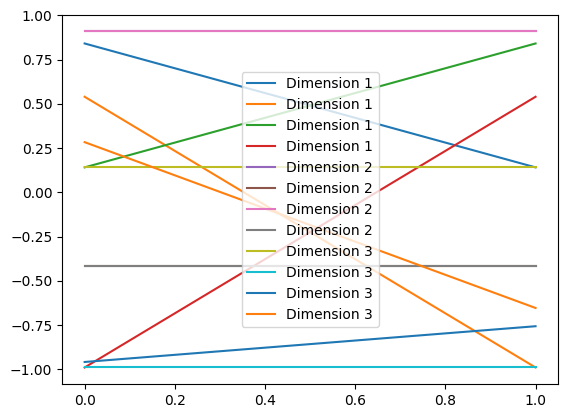

In [40]:
embeddings_np = embedding.cpu().detach().numpy()
# Plot each dimension of the embeddings
for i in range(embeddings_np.shape[1]):
    plt.plot(embeddings_np[:, i], label=f'Dimension {i+1}')

plt.legend()
plt.show()

In [58]:
import torch
import math

class SinusoidalPositionalEncoding1D(torch.nn.Module):
    def __init__(self, embed_dim, max_len=5000):
        super(SinusoidalPositionalEncoding1D, self).__init__()
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return x

class SinusoidalPositionalEncoding2D(torch.nn.Module):
    def __init__(self, embed_dim, height, width):
        super(SinusoidalPositionalEncoding2D, self).__init__()
        pe = torch.zeros(height, width, embed_dim)
        
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        
        pos_h = torch.arange(0, height).unsqueeze(1)
        pos_w = torch.arange(0, width).unsqueeze(1)
        
        pe[0::2, :, :] = torch.sin(pos_h * div_term).unsqueeze(2) + torch.sin(pos_w * div_term).unsqueeze(1)
        pe[1::2, :, :] = torch.cos(pos_h * div_term).unsqueeze(2) + torch.cos(pos_w * div_term).unsqueeze(1)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(2), :x.size(3)]
        return x


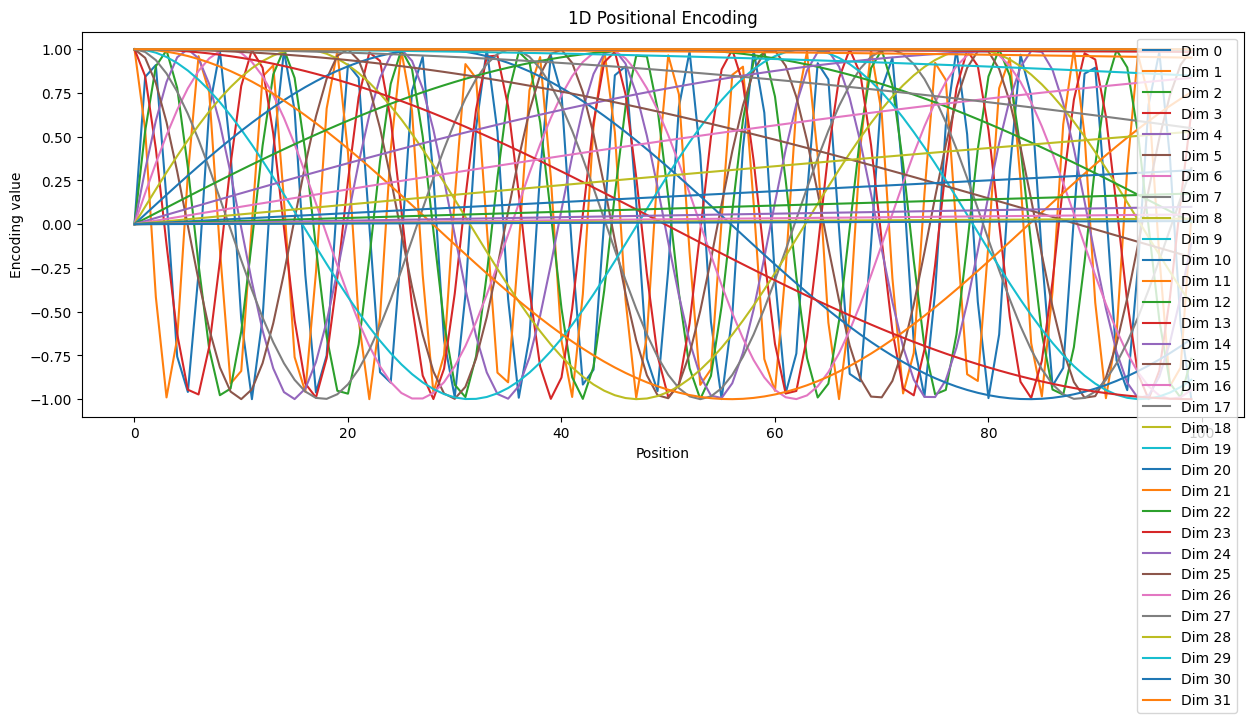

In [55]:
import matplotlib.pyplot as plt
embed_dim=32
max_len = 256
def visualize_positional_encoding_1d(pe, length=100):
    plt.figure(figsize=(15, 5))
    pe = pe[:length].detach().numpy()
    for i in range(pe.shape[1]):
        plt.plot(pe[:, i], label=f'Dim {i}')
    plt.legend(loc='upper right')
    plt.title('1D Positional Encoding')
    plt.xlabel('Position')
    plt.ylabel('Encoding value')
    plt.show()

# Assuming `embed_dim` and `max_len` are defined
pe_1d = SinusoidalPositionalEncoding1D(embed_dim, max_len).pe.squeeze(1)
visualize_positional_encoding_1d(pe_1d, length=100)


In [1]:
import numpy as np
from positional_encodings.torch_encodings import PositionalEncoding1D, PositionalEncoding2D, PositionalEncoding3D, Summer

p_enc_2d = PositionalEncoding2D(8)
height = 10
width = 10
def visualize_positional_encoding_2d(pe, height, width):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    pe = pe.detach().numpy()
    
    # Plot the first and second channels of the positional encoding
    axes[0].imshow(pe[0, :, :], cmap='viridis')
    axes[0].set_title('Positional Encoding (Channel 0)')
    axes[1].imshow(pe[1, :, :], cmap='viridis')
    axes[1].set_title('Positional Encoding (Channel 1)')
    
    plt.show()

import torch

# Create a random input tensor of shape (1, 1, 4, 4) with integers from 0 to 9
inputs = torch.randint(0, 10, (1, 1, 4, 4))
print(inputs)

p_enc_2d(inputs)

tensor([[[[9, 4, 3, 6],
          [4, 2, 9, 2],
          [9, 2, 0, 2],
          [3, 3, 2, 2]]]])


tensor([[[[0, 1, 0, 1],
          [0, 1, 0, 1],
          [0, 1, 0, 1],
          [0, 1, 0, 1]]]])

# Relative encodings

### Criteria 
* diffrentiable
* gives more precision the closer you are 
* allows model to predict 0, 0 to be the straignt line. already making it a way better prediction 
* maybe allow model to change the scal dynamically

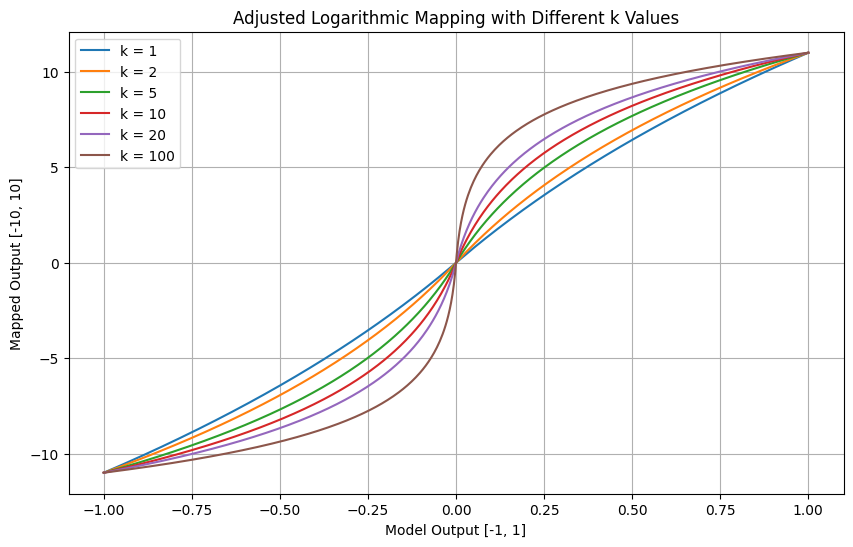

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Adjusted logarithmic mapping function
def adjusted_log_mapping(x, k=10):
    return np.sign(x) * (11 * np.log(k * np.abs(x) + 1) / np.log(k + 1))

# Generate x values from -1 to 1
x = np.linspace(-1, 1, 500)

# Calculate y values for different k values
k_values = [1, 2, 5, 10, 20, 100]
y_values = [adjusted_log_mapping(x, k) for k in k_values]

# Plot the results
plt.figure(figsize=(10, 6))
for k, y in zip(k_values, y_values):
    plt.plot(x, y, label=f'k = {k}')

plt.xlabel('Model Output [-1, 1]')
plt.ylabel('Mapped Output [-10, 10]')
plt.title('Adjusted Logarithmic Mapping with Different k Values')
plt.legend()
plt.grid(True)
plt.show()


### Dataset post processing to create mapping
* Assume u have n_waypoints on straigtline from start and end
* give me the path in terms of offset to that straight line

In [43]:
import wzk
from wzk import trajectory
indx = 80
sample = dataset[indx]
path = sample['path'].detach().cpu().numpy()
path
path_with_only_start_and_end = path[[0, -1]]
path_with_only_start_and_end
straight_line = trajectory.get_path_adjusted(path_with_only_start_and_end, n=20)
# Get the relaive offset of the straight line
offset_path = path - straight_line
offset_path

array([[ 0.        ,  0.        ],
       [-0.06042821, -0.00676732],
       [-0.12129538, -0.01486609],
       [-0.17229744, -0.01325486],
       [-0.20343944,  0.00470063],
       [-0.21689108,  0.0239618 ],
       [-0.21495713,  0.03597151],
       [-0.2027301 ,  0.03904483],
       [-0.1863616 ,  0.03656046],
       [-0.17030859,  0.0349085 ],
       [-0.15380699,  0.03258088],
       [-0.13727767,  0.03024012],
       [-0.12057634,  0.02777777],
       [-0.10368987,  0.02461259],
       [-0.08684978,  0.02134161],
       [-0.0696241 ,  0.01759242],
       [-0.0522183 ,  0.01358249],
       [-0.03485625,  0.00930359],
       [-0.01739215,  0.00467446],
       [ 0.        ,  0.        ]])

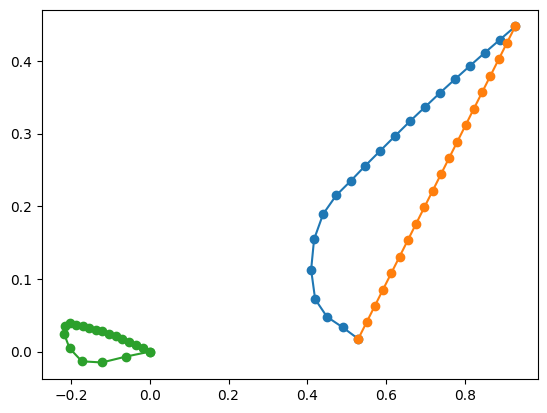

In [44]:
# plot the path and the straight line
plt.plot(path[:, 0], path[:, 1], '-o', label='Original Path')
plt.plot(straight_line[:, 0], straight_line[:, 1], '-o', label='Straight Line')
plt.plot(offset_path[:, 0], offset_path[:, 1], '-o', label='Offset Path')

In [45]:
(path == straight_line + offset_path)
path - straight_line - offset_path

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])